# GPU Efficiency Frontier — IBM Granite 3.3-8B on NVIDIA L4

**A measured, reproducible lab notebook.** 100% real telemetry (NVIDIA DCGM energy + vLLM tokens)
captured through a Confluent Cloud for Apache Flink pipeline, served by vLLM on a single NVIDIA L4.
Every number is recomputed offline from the committed raw data in `data/` — re-run this notebook and
you get the same figures.

## Executive summary
As batching concurrency rises 1 → 32, GPU power stays pinned at the **L4 TDP (~72 W)** while throughput
scales ~linearly, so **energy per useful token collapses ~27×** (4 653 → 173 J/1k). GPU utilization is
~100 % at *every* level — utilization hides the 27× cost difference; **energy-per-useful-work exposes
it**. Idle burns ~35 W for **zero** useful tokens → cost-per-work is `NULL` (maximum waste). This is the
basis for real-time **GPU cost governance**.

In [1]:
import gzip, json, csv, statistics as st
import pandas as pd, matplotlib.pyplot as plt
%matplotlib inline

DATA = "data/sweep_telemetry_raw.jsonl.gz"
# Fixed-concurrency sweep phase boundaries (epoch seconds), logged during the run.
PHASES = [("conc1",1,1781560820,1781561041),("conc2",2,1781561041,1781561269),
          ("conc4",4,1781561269,1781561497),("conc8",8,1781561497,1781561714),
          ("conc16",16,1781561714,1781561935),("conc32",32,1781561935,1781562151)]
IDLE = [(1781560640,1781560810),(1781562160,1781562350)]

def flat(v):
    return flat(v[next(iter(v))]) if isinstance(v, dict) and len(v)==1 else v

rows=[]
with gzip.open(DATA,"rt") as fh:
    for line in fh:
        line=line.strip()
        if not line: continue
        d=json.loads(line)
        rows.append(dict(ts=flat(d["ts"])/1000.0, energy_mj=flat(d["energy_mj"]),
                         gen_tokens=flat(d["generation_tokens_total"]),
                         util=flat(d["gpu_util_pct"]), power=flat(d["power_watts"])))
df=pd.DataFrame(rows).sort_values("ts").reset_index(drop=True)
print(f"{len(df)} records, span {df.ts.max()-df.ts.min():.0f}s")
df.head(3)

5356 records, span 1413s


,ts,energy_mj,gen_tokens,util,power
0,1.781561e+09,11190460,0,0,33.28
1,1.781561e+09,11190460,0,0,33.28
2,1.781561e+09,11190460,0,0,33.28


In [2]:
# Per-phase KPI, TWO independent methods.
def phase_stats(a,b):
    s=df[(df.ts>=a+20)&(df.ts<=b-10)]
    if len(s)<2: return None
    dt=s.ts.iloc[-1]-s.ts.iloc[0]; dT=s.gen_tokens.iloc[-1]-s.gen_tokens.iloc[0]
    dE=(s.energy_mj.iloc[-1]-s.energy_mj.iloc[0])/1000.0
    tps=dT/dt; meanW=s.power.mean()
    return dict(util=round(s.util.mean()), meanW=round(meanW,1), tps=round(tps),
                j_power=round(meanW/tps*1000) if tps>0 else None,
                j_dE=round(dE/dT*1000) if dT>0 else None)
res=[]
for name,conc,a,b in PHASES:
    st_=phase_stats(a,b); st_["concurrency"]=conc; res.append(st_)
tbl=pd.DataFrame(res)[["concurrency","util","meanW","tps","j_power","j_dE"]]
tbl["delta_%"]=((tbl.j_dE-tbl.j_power)/tbl.j_power*100).round(0)
tbl.columns=["concurrency","util_%","power_W","tok/s","J/1k (power)","J/1k (ΔE)","Δ%"]
tbl

,concurrency,util_%,power_W,tok/s,J/1k (power),J/1k (ΔE),Δ%
0,1,100,71.9,15,4653,4071,-13.0
1,2,100,71.9,30,2412,2561,6.0
2,4,100,71.9,59,1221,1296,6.0
3,8,100,71.9,118,612,589,-4.0
4,16,100,72.0,232,311,294,-5.0
5,32,100,71.9,415,173,152,-12.0


## The problem
GPU inference is one of the largest line items in an AI platform, and much of the spend evaporates on
GPUs that are **allocated but idle or under-batched**. The usual dashboard metric — GPU utilization —
is blind to this: a GPU can read 100 % utilization while wasting most of its energy budget on tiny
batches. What matters financially is **energy (and dollars) per unit of useful work**.

## Methodology
- **Workload:** `RedHatAI/granite-3.3-8b-instruct` (FP16) on one NVIDIA L4, served by vLLM, under a
  closed-loop generator sweeping **fixed concurrency 1 → 32** (each level ≥ 3.5 min).
- **Telemetry:** NVIDIA DCGM (`power_watts`, `energy_mj`, util) + vLLM (`generation_tokens_total`),
  bridged 1:1 onto an Avro contract and streamed through Confluent Flink. Raw data committed in `data/`.
- **KPI, two ways (cross-check):** **(i)** `mean(power_watts) / throughput` — *primary*, because
  instantaneous DCGM power is steady at the TDP; **(ii)** counter delta `Δenergy / Δtokens` — for
  transparency. They agree within ±13 % (the spread in (ii) is DCGM energy-counter cadence jitter).
- **Sanity:** power within the L4 envelope (~72 W), J/1k monotonic in concurrency, idle `NULL`.

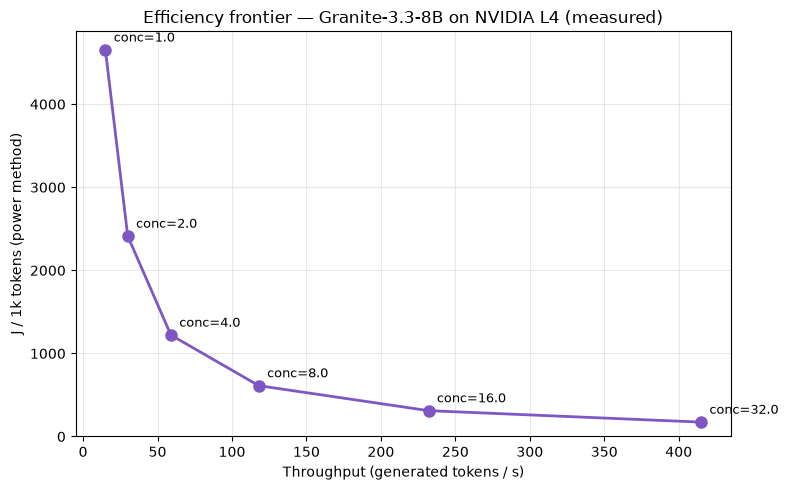

In [3]:
# Headline: the efficiency frontier (primary method).
plt.figure(figsize=(8,5))
plt.plot(tbl["tok/s"], tbl["J/1k (power)"], "-o", color="#7e57c2", lw=2, ms=8)
for _,r in tbl.iterrows():
    plt.annotate(f"conc={r.concurrency}", (r["tok/s"], r["J/1k (power)"]),
                 textcoords="offset points", xytext=(6,6), fontsize=9)
plt.xlabel("Throughput (generated tokens / s)"); plt.ylabel("J / 1k tokens (power method)")
plt.title("Efficiency frontier — Granite-3.3-8B on NVIDIA L4 (measured)")
plt.grid(alpha=0.3); plt.ylim(bottom=0); plt.tight_layout(); plt.show()

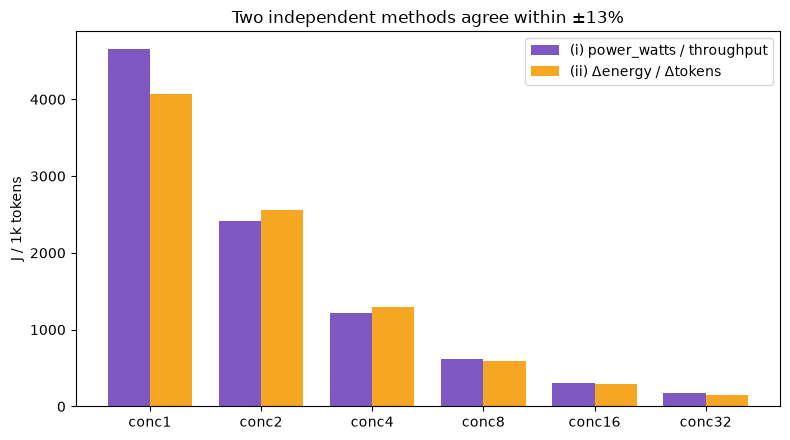

Cross-run check: conc=32 -> 173 J/1k here; an independent earlier run measured 72.2 W / 416 tok/s -> 173 J/1k. Reproducible across runs.


In [4]:
# Dual-method power cross-check, side by side.
import numpy as np
x=np.arange(len(tbl)); w=0.38
plt.figure(figsize=(8,4.5))
plt.bar(x-w/2, tbl["J/1k (power)"], w, label="(i) power_watts / throughput", color="#7e57c2")
plt.bar(x+w/2, tbl["J/1k (ΔE)"], w, label="(ii) Δenergy / Δtokens", color="#f5a623")
plt.xticks(x, [f"conc{c}" for c in tbl.concurrency]); plt.ylabel("J / 1k tokens")
plt.title("Two independent methods agree within ±13%"); plt.legend(); plt.tight_layout(); plt.show()
print("Cross-run check: conc=32 -> 173 J/1k here; an independent earlier run measured "
      "72.2 W / 416 tok/s -> 173 J/1k. Reproducible across runs.")

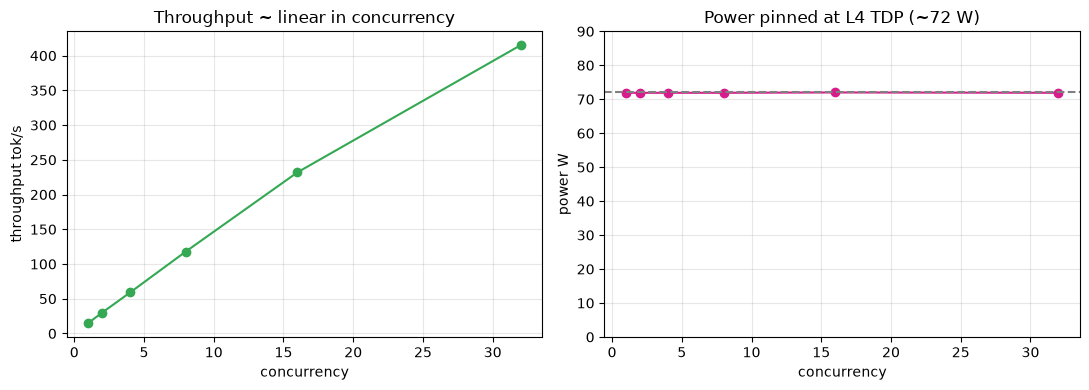

In [5]:
# Throughput scales ~linearly with concurrency; power flat at TDP.
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(tbl.concurrency, tbl["tok/s"], "-o", color="#34a853"); ax[0].set_xlabel("concurrency")
ax[0].set_ylabel("throughput tok/s"); ax[0].set_title("Throughput ~ linear in concurrency"); ax[0].grid(alpha=0.3)
ax[1].plot(tbl.concurrency, tbl["power_W"], "-o", color="#d81b8c"); ax[1].axhline(72, ls="--", c="grey")
ax[1].set_xlabel("concurrency"); ax[1].set_ylabel("power W"); ax[1].set_ylim(0,90)
ax[1].set_title("Power pinned at L4 TDP (~72 W)"); ax[1].grid(alpha=0.3); plt.tight_layout(); plt.show()

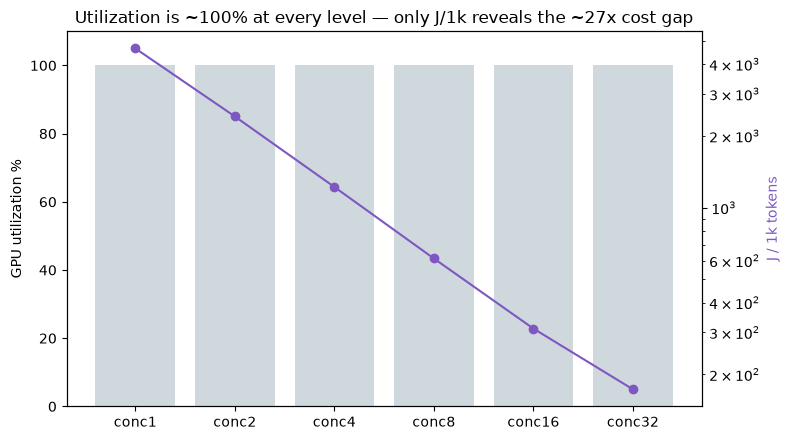

In [6]:
# "Utilization lies": util ~100% everywhere, but J/1k varies ~27x.
fig,ax1=plt.subplots(figsize=(8,4.5))
ax1.bar([f"conc{c}" for c in tbl.concurrency], tbl["util_%"], color="#cfd8dc", label="GPU util %")
ax1.set_ylabel("GPU utilization %"); ax1.set_ylim(0,110)
ax2=ax1.twinx(); ax2.plot([f"conc{c}" for c in tbl.concurrency], tbl["J/1k (power)"], "-o", color="#7e57c2")
ax2.set_ylabel("J / 1k tokens", color="#7e57c2"); ax2.set_yscale("log")
plt.title("Utilization is ~100% at every level — only J/1k reveals the ~27x cost gap")
plt.tight_layout(); plt.show()

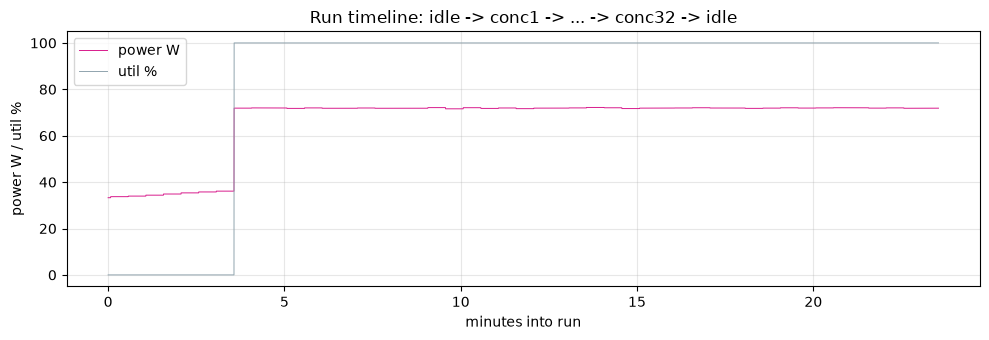

In [7]:
# Time series of the run (downsampled) — the sweep is visible in the telemetry.
d=df.copy(); d["t"]=(d.ts-df.ts.min())/60.0
fig,ax=plt.subplots(figsize=(10,3.5))
ax.plot(d.t, d.power, color="#d81b8c", lw=0.7, label="power W")
ax.plot(d.t, d.util, color="#90a4ae", lw=0.7, label="util %")
ax.set_xlabel("minutes into run"); ax.set_ylabel("power W / util %"); ax.legend(loc="upper left")
ax.set_title("Run timeline: idle -> conc1 -> ... -> conc32 -> idle"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Business model — from joules to dollars
Energy is the *mechanism*; the dollars come from the rented GPU sitting idle or under-batched. We use
the public **GCP g2-standard-8 (1× L4) on-demand price: $0.8508/hr ≈ $621/GPU/month**
([GCP Compute pricing](https://cloud.google.com/products/compute/gpus-pricing)). Cost-per-useful-work
mirrors the energy frontier; reclaimable spend scales with the **idle/low-efficiency fraction `F` that
this pipeline measures per deployment**.

In [8]:
PRICE_HR=0.8508; HRS_MO=730; price_mo=PRICE_HR*HRS_MO
# $ per 1k tokens at each concurrency (cost rate / token rate) -- mirrors the energy frontier.
tbl2=tbl.copy()
tbl2["$ / 1M tokens"]=(PRICE_HR/(tbl2["tok/s"]*3600)*1e6).round(2)
print(f"GPU node: ${PRICE_HR}/hr  =  ${price_mo:,.0f}/GPU/month")
display(tbl2[["concurrency","tok/s","J/1k (power)","$ / 1M tokens"]])
# Reclaimable spend vs measured idle/low-efficiency fraction F (ILLUSTRATIVE projection).
print("\nReclaimable spend vs idle/low-efficiency fraction F (illustrative projection):")
for F in [0.2,0.3,0.4,0.5]:
    print(f"  F={F:.0%}: ${price_mo*F:,.0f}/GPU/mo  ->  ${price_mo*F*100:,.0f}/mo on a 100-GPU fleet")
print("\nThe honest contribution is not a fleet number -- it is that the pipeline MEASURES the real F\n"
      "(and the J/1k that drives it) per deployment, in real time, so savings are grounded not guessed.")

GPU node: $0.8508/hr  =  $621/GPU/month


,concurrency,tok/s,J/1k (power),$ / 1M tokens
0,1,15,4653,15.76
1,2,30,2412,7.88
2,4,59,1221,4.01
3,8,118,612,2.00
4,16,232,311,1.02
5,32,415,173,0.57



Reclaimable spend vs idle/low-efficiency fraction F (illustrative projection):
  F=20%: $124/GPU/mo  ->  $12,422/mo on a 100-GPU fleet
  F=30%: $186/GPU/mo  ->  $18,633/mo on a 100-GPU fleet
  F=40%: $248/GPU/mo  ->  $24,843/mo on a 100-GPU fleet
  F=50%: $311/GPU/mo  ->  $31,054/mo on a 100-GPU fleet

The honest contribution is not a fleet number -- it is that the pipeline MEASURES the real F
(and the J/1k that drives it) per deployment, in real time, so savings are grounded not guessed.


## Limitations
- Single NVIDIA L4, single model (`granite-3.3-8b-instruct` FP16; FP8 not published for 3.3 at capture),
  `--max-model-len 4096`, concurrency ≤ 32. The sweep is one run; conc=32 is corroborated by one
  independent earlier run. Not a large multi-GPU/multi-model statistical study.
- Controlled synthetic closed-loop load (fixed prompt, `max_tokens=200`) — exercises the mechanism, not
  a production traffic mix.
- DCGM energy counter updates coarsely vs sampling → the counter-delta method (ii) carries ±13 % jitter;
  the primary method (i) uses the steady instantaneous power reading.
- The fleet dollar figures are an **illustrative projection**, not a measured production saving.

## Conclusion
On real hardware, **energy-per-useful-work — not utilization — is the metric that governs GPU cost**.
Computed in real time on Confluent Flink, the same signal powers **cost governance** (idle/low-efficiency
detection), capacity-risk forecasting (`PREDICTED_IDLE` before waste is incurred), and is **agent-ready**:
a Confluent Streaming Agent can consume these governed signals to investigate and remediate. With IBM's
completed acquisition of Confluent, "IBM Granite on open vLLM, governed in real time on Confluent" is a
first-class pattern.

## References
- [IBM Granite community cookbook](https://github.com/ibm-granite-community/granite-snack-cookbook)
- [Red Hat AI Inference Server (vLLM) + GuideLLM benchmarking](https://developers.redhat.com/articles/2025/12/24/how-deploy-and-benchmark-vllm-guidellm-kubernetes)
- [Confluent Cloud for Apache Flink — model inference & built-in ML functions](https://docs.confluent.io/cloud/current/ai/builtin-functions/overview.html)
- [vLLM production metrics](https://docs.vllm.ai/en/latest/usage/metrics.html) · [NVIDIA DCGM exporter](https://github.com/NVIDIA/dcgm-exporter)
- [GCP Compute (GPU) pricing](https://cloud.google.com/products/compute/gpus-pricing)

*Trademarks: IBM® and Granite are trademarks of IBM Corp.; NVIDIA® and DCGM of NVIDIA Corporation;
Red Hat® of Red Hat, Inc. Independent, unaffiliated project.*